# CreditGuard AI - Credit Card Approval Preddiction

## Part 1: Data Cleaning and Exploratory Data Analysis

This notebook performs complete data preparation and analysis on the Credit Card Approval Prediction dataset.

Objectives:

- Load and inspect raw customer data
- Identify missing values
- Handle incorrect data types
- Remove duplicates
- Analyze statistical properties
- Detect skewness and outliers
- Create visualizations
- Study feature relationships

The cleaned dataset will be used for Machine Learning model development.

## 1. Import Required Libraries

Pandas and NumPy are used for data processing.

Matplotlib and Seaborn are used for data visualization.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings

warnings.filterwarnings("ignore")


os.makedirs(
    "plots",
    exist_ok=True
)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset

The raw credit card customer dataset is loaded using pandas read_csv().


In [3]:
df = pd.read_csv("/content/application_record.csv")
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0


## 3. Initial Data Inspection

Before cleaning, we inspect:

- First rows
- Column data types
- Dataset dimensions

In [4]:
print("Dataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

Dataset Shape
(33846, 18)

Data Types
ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH             float64
DAYS_EMPLOYED          float64
FLAG_MOBIL             float64
FLAG_WORK_PHONE        float64
FLAG_PHONE             float64
FLAG_EMAIL             float64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
dtype: object


## 4. Null Value Analysis

Missing values are identified using:

- Missing count
- Missing percentage

Columns above 20% missing values are reported separately.

In [5]:
null_count = df.isnull().sum()
null_percentage = (null_count/df.shape[0])*100

null_table = pd.DataFrame({"Missing Count":null_count,"Missing Percentage":null_percentage})
null_table

,Missing Count,Missing Percentage
ID,0,0.000000
CODE_GENDER,0,0.000000
FLAG_OWN_CAR,0,0.000000
FLAG_OWN_REALTY,0,0.000000
CNT_CHILDREN,0,0.000000
AMT_INCOME_TOTAL,0,0.000000
NAME_INCOME_TYPE,0,0.000000
NAME_EDUCATION_TYPE,0,0.000000
NAME_FAMILY_STATUS,0,0.000000
NAME_HOUSING_TYPE,0,0.000000


In [6]:
above_20 = null_table[null_table["Missing Percentage"]>20]
above_20

,Missing Count,Missing Percentage
OCCUPATION_TYPE,10704,31.625598


## Missing Value Treatment

For numeric columns with less than 20% missing data, median imputation is used.

Median is selected because financial data contains extreme values and median is less affected by outliers compared with mean.

For columns with more than 20% missing data , the column is dropped.

In [7]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns


for col in numeric_cols:
    if df[col].isnull().mean()<0.20:
        df[col]=df[col].fillna(df[col].median())


df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [9]:
df.drop(above_20.index,axis=1,inplace=True)
df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


## 5. Duplicate Detection and Removal

In [8]:
duplicates = df.duplicated().sum()


print("Duplicate Rows:",duplicates)
before=df.shape[0]
df=df.drop_duplicates()
after=df.shape[0]
print("Rows Removed:",before-after)

Duplicate Rows: 0
Rows Removed: 0


## 6. Data Type Correction and Memory Optimization

Categorical variables are converted from object datatype into category datatype to reduce memory usage.

In [10]:
before_memory = (df.memory_usage(deep=True).sum())


print("Memory Before:",before_memory)

df["NAME_EDUCATION_TYPE"] = (df["NAME_EDUCATION_TYPE"].astype("category"))
after_memory = (df.memory_usage(deep=True).sum())


print("Memory After:",after_memory)

Memory Before: 16514452
Memory After: 14047193


## 7. Feature Engineering

DAYS_BIRTH contains negative day values.

It is converted into customer AGE.

In [11]:
df["AGE"] = (abs(df["DAYS_BIRTH"])/365).astype(int)
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,2.0,32
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,2.0,32
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,2.0,58
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,1.0,52
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,1.0,52


## 8. Descriptive Statistics

In [12]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE
count,3.384600e+04,33846.000000,3.384600e+04,33846.000000,33846.000000,33846.0,33846.000000,33846.000000,33846.000000,33846.000000,33846.000000
mean,5.314423e+06,0.406252,1.878978e+05,-16246.487473,64116.600366,1.0,0.206258,0.298972,0.097560,2.175471,44.002216
std,4.800115e+05,0.720795,1.019862e+05,4185.915627,141931.649124,0.0,0.404624,0.457814,0.296723,0.886378,11.469480
min,5.008804e+06,0.000000,3.015000e+04,-25140.000000,-15227.000000,1.0,0.000000,0.000000,0.000000,1.000000,20.000000
25%,5.041136e+06,0.000000,1.215000e+05,-19791.000000,-3246.000000,1.0,0.000000,0.000000,0.000000,2.000000,34.000000
50%,5.068076e+06,0.000000,1.575000e+05,-15851.000000,-1563.000000,1.0,0.000000,0.000000,0.000000,2.000000,43.000000
75%,5.438602e+06,1.000000,2.250000e+05,-12763.000000,-387.000000,1.0,0.000000,1.000000,0.000000,3.000000,54.000000
max,6.836568e+06,14.000000,1.350000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,68.000000


## 9. Skewness Analysis

Skewness explains the symmetry of data distribution.

Positive skew:
Extreme high values pull the mean upward.

Negative skew:
Extreme low values pull the mean downward.

In [13]:
numeric_cols=df.select_dtypes(include=["int64","float64"]).columns

skew_values={}
for col in numeric_cols:
    skew_values[col]=df[col].skew()
skew_values

{'ID': np.float64(1.7341661157107786),
 'CNT_CHILDREN': np.float64(2.301139058639561),
 'AMT_INCOME_TOTAL': np.float64(2.528804252972985),
 'DAYS_BIRTH': np.float64(-0.13706502765783324),
 'DAYS_EMPLOYED': np.float64(1.649779925137042),
 'FLAG_MOBIL': np.float64(0.0),
 'FLAG_WORK_PHONE': np.float64(1.4520138567290297),
 'FLAG_PHONE': np.float64(0.8782604691222853),
 'FLAG_EMAIL': np.float64(2.7127311008175106),
 'CNT_FAM_MEMBERS': np.float64(1.1411290125616884),
 'AGE': np.float64(0.1376922111821884)}

In [15]:
most_skewed=max(skew_values,key=lambda x:abs(skew_values[x]))

print("Highest Skew Column:",most_skewed)
print("Value:",skew_values[most_skewed])

Highest Skew Column: FLAG_EMAIL
Value: 2.7127311008175106


## 10. IQR Outlier Detection

The Inter Quartile Range (IQR) method is used to detect extreme values.

Formula:

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR


Outliers are detected but not removed because extreme income values may represent real customers.

In [17]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower)|(df[column] > upper)]
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Outlier Count:",len(outliers))
    print("-"*40)

detect_outliers("AMT_INCOME_TOTAL")
detect_outliers("AGE")

Column: AMT_INCOME_TOTAL
Q1: 121500.0
Q3: 225000.0
IQR: 103500.0
Lower Bound: -33750.0
Upper Bound: 380250.0
Outlier Count: 1421
----------------------------------------
Column: AGE
Q1: 34.0
Q3: 54.0
IQR: 20.0
Lower Bound: 4.0
Upper Bound: 84.0
Outlier Count: 0
----------------------------------------


# 11. Data Visualization

Five visualizations are created:

1. Line plot
2. Bar chart
3. Histogram
4. Scatter plot
5. Box plot


## Line Plot

Shows customer age trend across dataset records.

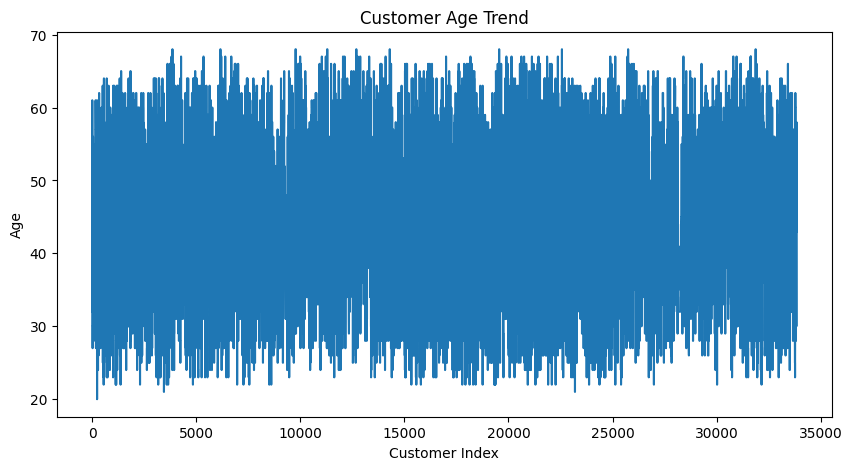

In [18]:
plt.figure(figsize=(10,5))
plt.plot(df["AGE"])
plt.title("Customer Age Trend")
plt.xlabel("Customer Index")
plt.ylabel("Age")
plt.savefig("plots/age_line_plot.png")
plt.show()

## Bar Chart

This compares average income across different education categories.

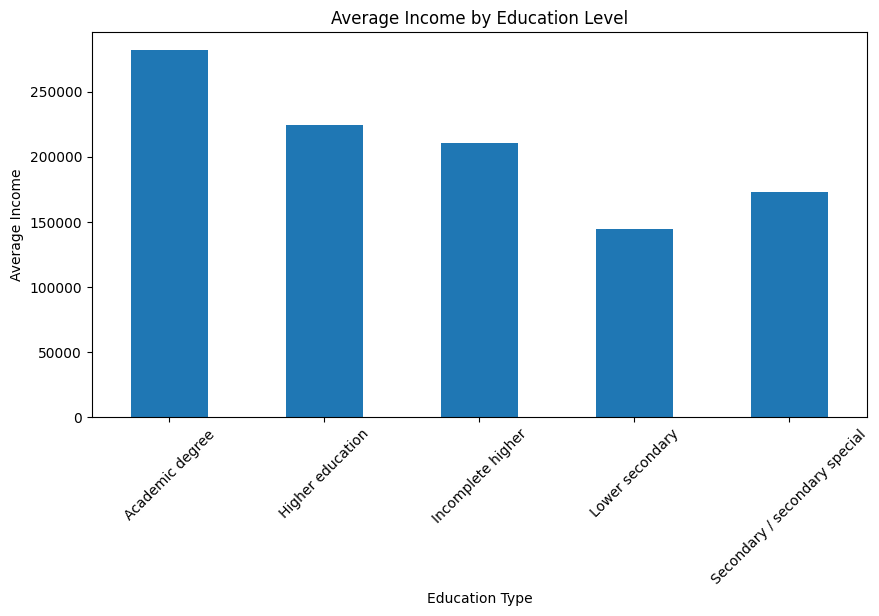

In [20]:
education_income = (df.groupby("NAME_EDUCATION_TYPE")["AMT_INCOME_TOTAL"].mean())
plt.figure(figsize=(10,5))
education_income.plot(kind="bar")
plt.title("Average Income by Education Level")
plt.xlabel("Education Type")
plt.ylabel("Average Income")
plt.xticks(rotation=45)
plt.savefig("plots/education_income_bar.png")
plt.show()

## Histogram

The most skewed numerical feature is visualized to understand its distribution.

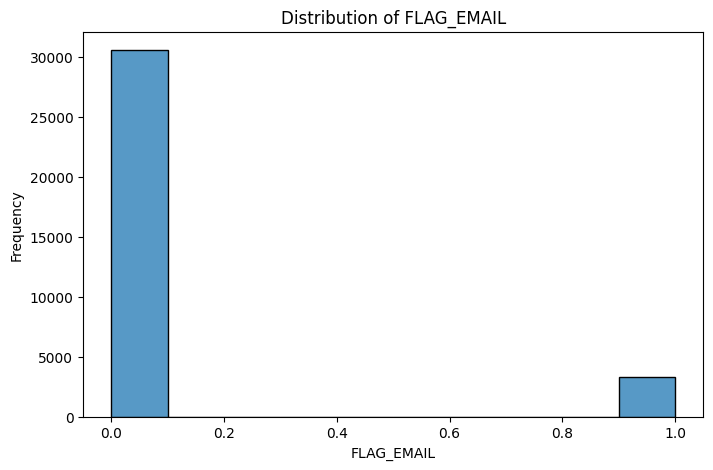

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df[most_skewed],bins=10)
plt.title(f"Distribution of {most_skewed}")
plt.xlabel(most_skewed)
plt.ylabel("Frequency")
plt.savefig("plots/skew_histogram.png")
plt.show()

## Scatter Plot

The relationship between customer age and income is analyzed.

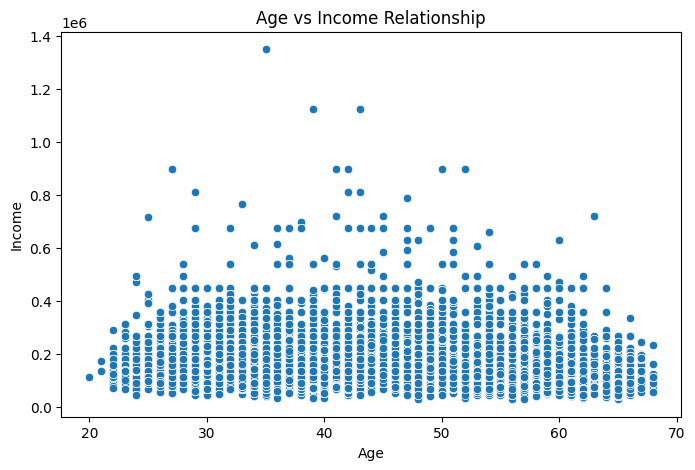

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="AGE",y="AMT_INCOME_TOTAL")
plt.title("Age vs Income Relationship")
plt.xlabel("Age")
plt.ylabel("Income")
plt.savefig("plots/age_income_scatter.png")
plt.show()

## Box Plot

The boxplot compares income distribution among education categories.

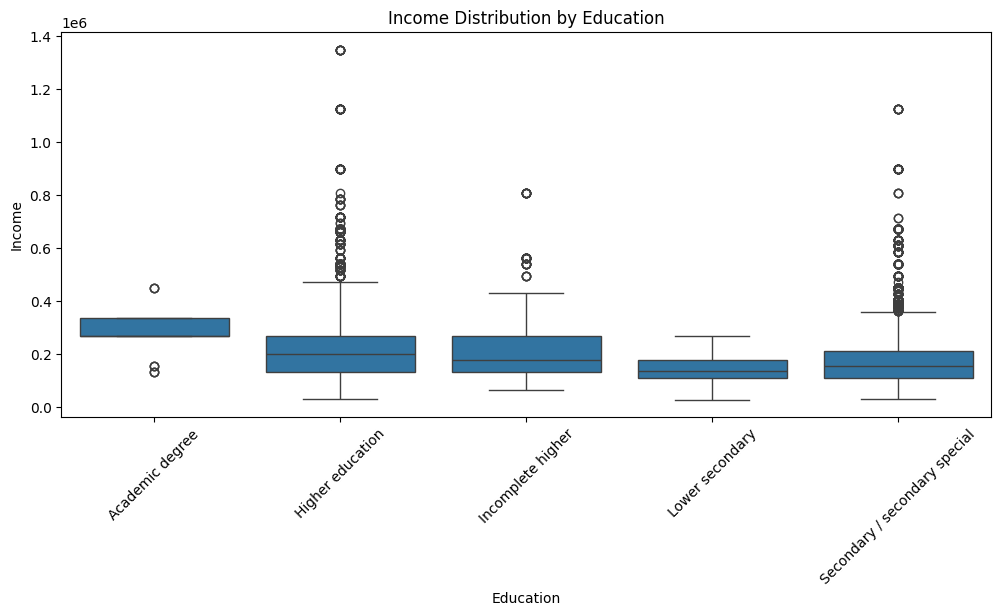

In [25]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x="NAME_EDUCATION_TYPE",y="AMT_INCOME_TOTAL")
plt.xticks(rotation=45)
plt.title("Income Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Income")
plt.savefig("plots/income_boxplot.png")
plt.show()

# 12. Pearson Correlation Heatmap

Pearson correlation measures the linear relationship between numerical variables.

Values range:

+1 = strong positive relationship

0 = no relationship

-1 = strong negative relationship

In [26]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=["int64","float64"])

# Pearson correlation
pearson_corr = numeric_df.corr()

print("Pearson Correlation Matrix")
pearson_corr

Pearson Correlation Matrix


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE
ID,1.000000,-0.002334,-0.002533,-0.022677,0.008646,NaN,0.000425,0.014351,-0.009329,0.021111,0.022668
CNT_CHILDREN,-0.002334,1.000000,0.054337,0.357951,-0.234203,NaN,0.026842,-0.018701,0.023976,0.882525,-0.357701
AMT_INCOME_TOTAL,-0.002533,0.054337,1.000000,0.086392,-0.179963,NaN,-0.026556,0.012064,0.090960,0.045304,-0.086268
DAYS_BIRTH,-0.022677,0.357951,0.086392,1.000000,-0.629791,NaN,0.184830,-0.035195,0.109024,0.318040,-0.999682
DAYS_EMPLOYED,0.008646,-0.234203,-0.179963,-0.629791,1.000000,NaN,-0.240486,-0.000545,-0.086545,-0.227202,0.629147
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.000425,0.026842,-0.026556,0.184830,-0.240486,NaN,1.000000,0.302555,-0.032254,0.037981,-0.185266
FLAG_PHONE,0.014351,-0.018701,0.012064,-0.035195,-0.000545,NaN,0.302555,1.000000,-0.000697,-0.010091,0.034705
FLAG_EMAIL,-0.009329,0.023976,0.090960,0.109024,-0.086545,NaN,-0.032254,-0.000697,1.000000,0.029388,-0.108838
CNT_FAM_MEMBERS,0.021111,0.882525,0.045304,0.318040,-0.227202,NaN,0.037981,-0.010091,0.029388,1.000000,-0.317928


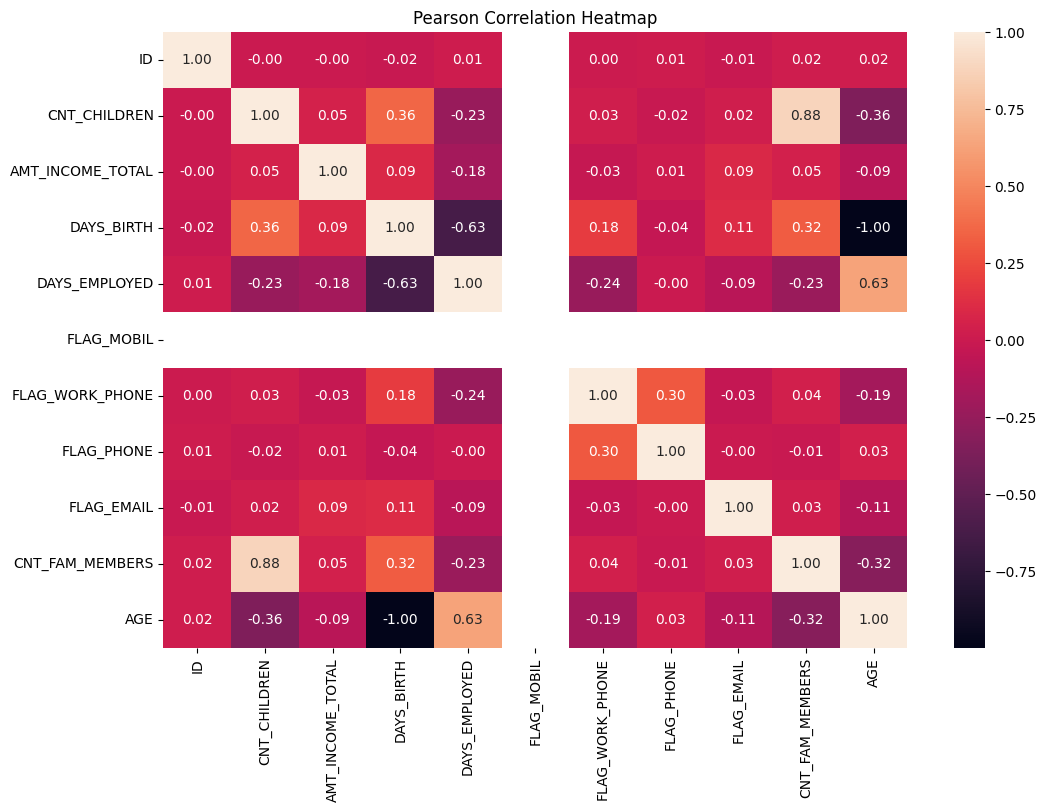

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(pearson_corr,annot=True,fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.savefig("plots/correlation_heatmap.png")
plt.show()

## Highest Correlation Pair

The strongest relationship between two numeric variables is identified.

In [29]:
corr_pairs = (pearson_corr.abs().unstack().sort_values(ascending=False))

# Remove self correlation
corr_pairs = corr_pairs[corr_pairs < 1]
highest_corr = corr_pairs.head(1)

print("Highest Correlation Pair:")
print(highest_corr)

Highest Correlation Pair:
DAYS_BIRTH  AGE    0.999682
dtype: float64


The highest correlated variables were identified using Pearson correlation.

Correlation does not always indicate causation.

A third factor such as employment status, education, or financial background may influence both variables.}

# 13. Mean vs Median Comparison for Skewed Columns

The two highest skewed columns are analyzed.

Mean and median values are compared before choosing an imputation strategy.

In [31]:
top_two_skewed = (pd.Series(skew_values).abs().sort_values(ascending=False).head(2).index)


for col in top_two_skewed:

    print("\nColumn:",col)
    print("Mean:",df[col].mean())


    print("Median:",df[col].median())


Column: FLAG_EMAIL
Mean: 0.09755953436151983
Median: 0.0

Column: AMT_INCOME_TOTAL
Mean: 187897.83571175323
Median: 157500.0


In [32]:
for col in top_two_skewed:

    df[col] = (df[col].fillna(df[col].median()))

print("Remaining Null Values")
df.isnull().sum()

Remaining Null Values


,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


Median was selected for imputation.

For positively skewed columns, extreme high values pull the mean upward.

For negatively skewed columns, extreme low values pull the mean downward.

Median gives a more reliable central value.

# 14. Spearman Rank Correlation

Spearman correlation measures monotonic relationships.

Unlike Pearson, it works on ranks and can identify non-linear relationships.

In [33]:
spearman_corr = df.corr(method="spearman",numeric_only=True)

print("Spearman Correlation Matrix")
spearman_corr

Spearman Correlation Matrix


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE
ID,1.000000,-0.006724,-0.012125,-0.016347,-0.018260,NaN,0.040550,0.024061,-0.014068,0.011651,0.016292
CNT_CHILDREN,-0.006724,1.000000,0.052741,0.401461,-0.136157,NaN,0.024126,-0.025529,0.033137,0.814786,-0.401326
AMT_INCOME_TOTAL,-0.012125,0.052741,1.000000,0.110901,-0.183391,NaN,-0.042623,-0.009643,0.085439,0.027439,-0.110981
DAYS_BIRTH,-0.016347,0.401461,0.110901,1.000000,-0.242562,NaN,0.180921,-0.036503,0.109251,0.320357,-0.999685
DAYS_EMPLOYED,-0.018260,-0.136157,-0.183391,-0.242562,1.000000,NaN,-0.176275,-0.035901,-0.026044,-0.141226,0.242734
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.040550,0.024126,-0.042623,0.180921,-0.176275,NaN,1.000000,0.302555,-0.032254,0.036837,-0.181224
FLAG_PHONE,0.024061,-0.025529,-0.009643,-0.036503,-0.035901,NaN,0.302555,1.000000,-0.000697,-0.013351,0.036105
FLAG_EMAIL,-0.014068,0.033137,0.085439,0.109251,-0.026044,NaN,-0.032254,-0.000697,1.000000,0.033725,-0.109099
CNT_FAM_MEMBERS,0.011651,0.814786,0.027439,0.320357,-0.141226,NaN,0.036837,-0.013351,0.033725,1.000000,-0.320405


In [34]:
difference = abs(spearman_corr-pearson_corr)

print("Difference Matrix")
difference

Difference Matrix


,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,AGE
ID,0.000000,0.004389,0.009592,0.006330,0.026907,NaN,4.012478e-02,9.710542e-03,4.739444e-03,0.009461,0.006376
CNT_CHILDREN,0.004389,0.000000,0.001595,0.043510,0.098046,NaN,2.716321e-03,6.828495e-03,9.160676e-03,0.067739,0.043625
AMT_INCOME_TOTAL,0.009592,0.001595,0.000000,0.024509,0.003428,NaN,1.606694e-02,2.170690e-02,5.521302e-03,0.017865,0.024713
DAYS_BIRTH,0.006330,0.043510,0.024509,0.000000,0.387229,NaN,3.908880e-03,1.308522e-03,2.275928e-04,0.002316,0.000003
DAYS_EMPLOYED,0.026907,0.098046,0.003428,0.387229,0.000000,NaN,6.421060e-02,3.535635e-02,6.050077e-02,0.085976,0.386413
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.040125,0.002716,0.016067,0.003909,0.064211,NaN,0.000000e+00,6.661338e-16,4.857226e-17,0.001144,0.004042
FLAG_PHONE,0.009711,0.006828,0.021707,0.001309,0.035356,NaN,6.661338e-16,0.000000e+00,2.146720e-16,0.003260,0.001401
FLAG_EMAIL,0.004739,0.009161,0.005521,0.000228,0.060501,NaN,4.857226e-17,2.146720e-16,0.000000e+00,0.004338,0.000261
CNT_FAM_MEMBERS,0.009461,0.067739,0.017865,0.002316,0.085976,NaN,1.144401e-03,3.260318e-03,4.337771e-03,0.000000,0.002477


In [35]:
top_three_difference = (difference.unstack().sort_values(ascending=False).head(3))

print("Top 3 Pearson vs Spearman Differences")

print(top_three_difference)

Top 3 Pearson vs Spearman Differences
DAYS_BIRTH     DAYS_EMPLOYED    0.387229
DAYS_EMPLOYED  DAYS_BIRTH       0.387229
               AGE              0.386413
dtype: float64


The largest differences between Pearson and Spearman correlations were analyzed.

If Spearman is higher than Pearson, the relationship is monotonic but not perfectly linear.

For feature selection, both methods will be considered because financial data often contains non-linear relationships.

# 15. Grouped Aggregation Analysis

Education category is compared with income.

Mean, standard deviation and record count are calculated.

In [36]:
group_analysis = (df.groupby("NAME_EDUCATION_TYPE")["AMT_INCOME_TOTAL"].agg(["mean","std","count"]))
group_analysis

,mean,std,count
NAME_EDUCATION_TYPE,,,
Academic degree,281637.931034,89115.885283,29
Higher education,224347.271874,123430.279235,9212
Incomplete higher,210691.089965,110312.354723,1156
Lower secondary,144605.322581,57818.782396,310
Secondary / secondary special,172710.533256,87555.671836,23139


In [37]:
highest_mean = (group_analysis["mean"].idxmax())
highest_std = (group_analysis["std"].idxmax())

ratio = (group_analysis["mean"].max()/group_analysis["mean"].min())

print("Highest Mean Group:",highest_mean)
print( "Highest STD Group:",highest_std)
print("Mean Ratio:",ratio)

Highest Mean Group: Academic degree
Highest STD Group: Higher education
Mean Ratio: 1.9476318437546842


The group with highest mean income was identified.

A high standard deviation indicates large variation inside that group.

This means education alone cannot fully predict customer income.

Other features are required for accurate prediction.

# 16. Save Clean Dataset

The final processed dataset is saved for Machine Learning.

In [38]:
df.to_csv(
"cleaned_credit_data.csv",index=False)

print("Clean dataset saved successfully")

Clean dataset saved successfully
